# Project Overview: Cat vs Dog
**Objective:** To classify images of cats and dogs, focusing on optimizing model architecture and fine-tuning hyperparameter configurations through robust regularization techniques to minimize validation errors and maximize the final Test Accuracy metric.

## 1. Libraries & Workspace Setup

In [3]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('image-classification-challenge-haradi')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/image-classification-challenge-haradi


In [4]:
import cv2
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os
import matplotlib.image as mpimg
warnings.filterwarnings('ignore', category=FutureWarning)
import os
import glob
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers
from sklearn.utils import class_weight
from tensorflow.keras.optimizers import RMSprop
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from IPython.display import FileLink
from tensorflow.keras.applications import ResNet50

## 2. Data & Visual Integrity Verification

In [5]:
base_path = "/kaggle/input/image-classification-challenge-haradi/data file/img/test/"

In [6]:
df=pd.read_csv('/kaggle/input/competitions/image-classification-challenge-haradi/data file/ground_truth.csv')

In [7]:
df

,img,is_dog
0,0,1
1,1,0
2,2,1
3,3,0
4,4,1
...,...,...
995,995,0
996,996,0
997,997,0
998,998,0


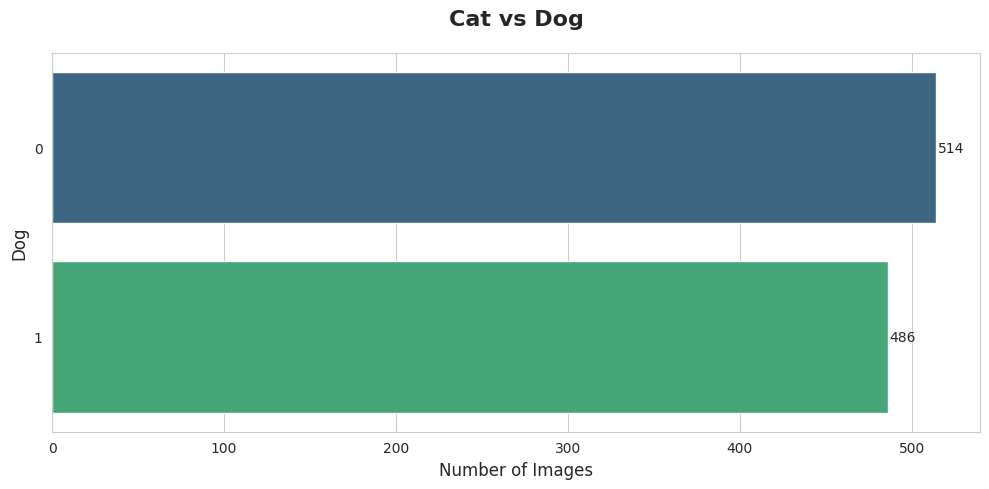

In [8]:
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

order = df['is_dog'].value_counts().index

ax = sns.countplot(y='is_dog', data=df, order=order, palette='viridis')

plt.title('Cat vs Dog', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Dog', fontsize=12)

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 1, p.get_y() + p.get_height()/2, 
            f'{int(width)}', 
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

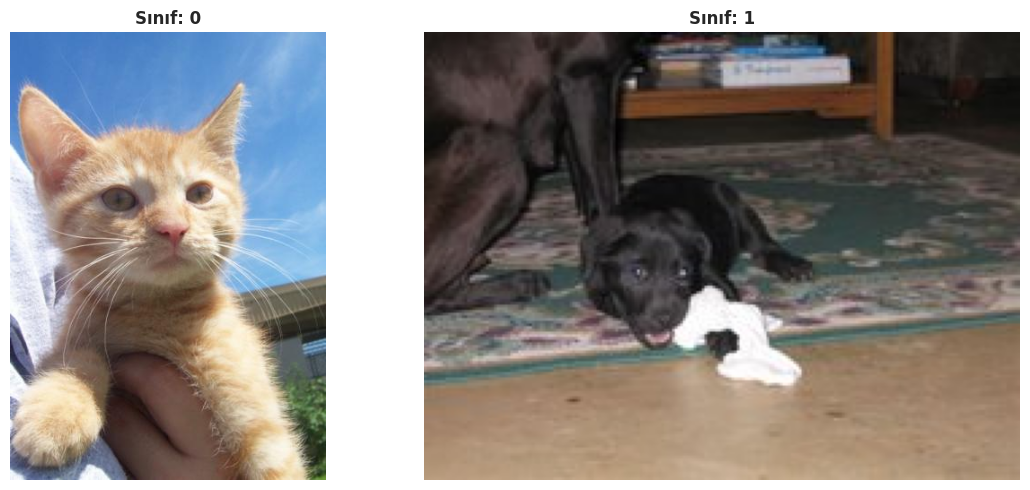

In [9]:
base_path = '/kaggle/input/competitions/image-classification-challenge-haradi/data file/img/test/'

df['img'] = df['img'].astype(str).str.strip()

sample_df = df.groupby('is_dog').sample(n=1, random_state=42).sort_values('is_dog')

num_classes = len(sample_df)
n_cols = 2
n_rows = (num_classes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
if num_classes > 1:
    axes = axes.flatten()
else:
    axes = [axes]


for i, (idx, row) in enumerate(sample_df.iterrows()):
    file_id = row['img']
    if not file_id.endswith('.jpg'):
        img_filename = file_id + '.jpg'
    else:
        img_filename = file_id
        
    img_path = os.path.join(base_path, img_filename)
    
    try:
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"Sınıf: {row['is_dog']}", fontsize=12, fontweight='bold')
    except Exception as e:
        axes[i].set_title(f"Hata: {row['is_dog']}", fontsize=10, color='red')
        print(f"Hata: {img_path} bulunamadı. Detay: {e}")
    
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [10]:
path = '/kaggle/input/competitions/image-classification-challenge-haradi/data file/img/test/'

x = []
y = []

for index, row in df.iterrows():
    file_name = str(row['img']) + '.jpg'
    img_path = os.path.join(path, file_name)
    
    img = cv2.imread(img_path)
    
    if img is not None:
        img = cv2.resize(img, (120, 120))
        img = img / 255.0
        x.append(img)
        
        y.append(row['is_dog'])
    else:
        print(f"Warning: {img_path} can not find.")


Corrupt JPEG data: 99 extraneous bytes before marker 0xd9


In [11]:
x = np.array(x)
y = np.array(y)

In [12]:
x.shape

(1000, 120, 120, 3)

In [13]:
y.shape

(1000,)

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y, random_state=42, stratify=df["is_dog"], test_size=.20)

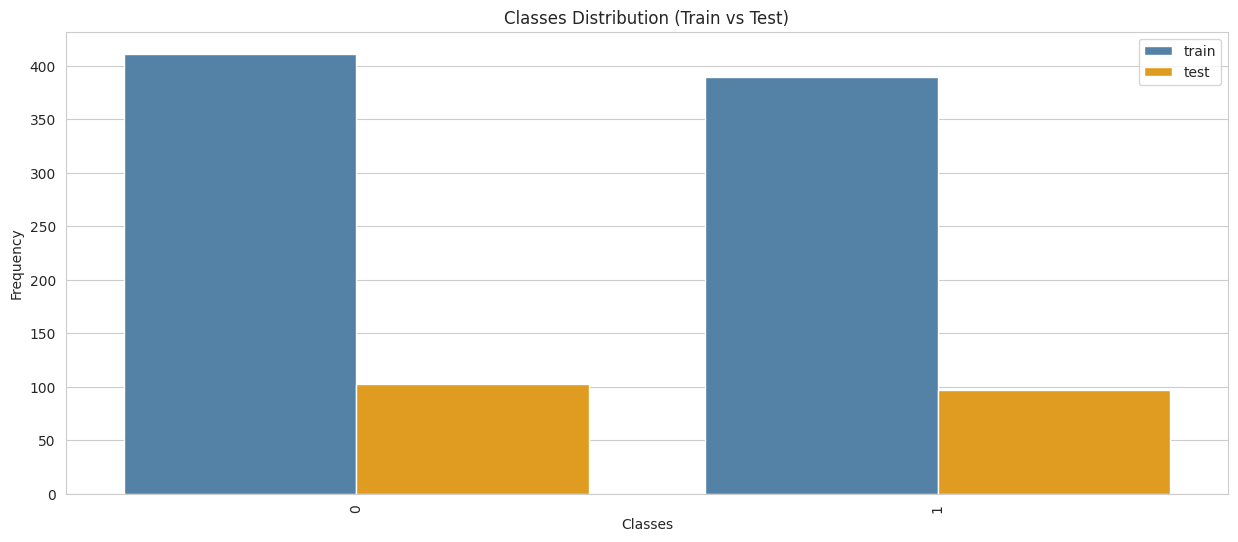

In [15]:
y_train_flat = np.array(y_train).flatten()
y_test_flat = np.array(y_test).flatten()

df_train = pd.DataFrame({'Label': y_train_flat, 'Dataset': 'train'})
df_test = pd.DataFrame({'Label': y_test_flat, 'Dataset': 'test'})
df_combined = pd.concat([df_train, df_test])

plt.figure(figsize=(15, 6))

sns.countplot(data=df_combined, x='Label', hue='Dataset', palette=['steelblue', 'orange'])

plt.xticks(rotation=90)
plt.xlabel('Classes')
plt.ylabel('Frequency')
plt.title('Classes Distribution (Train vs Test)')
plt.legend()
plt.show()

## 3. Neural Network Architecture & Model Training & Convergence Performance

In [16]:
model = Sequential([
    Input(shape=(120, 120, 3)),
    
    Conv2D(32, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.001)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.001)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.3),
    
    Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.001)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.4),
    
    Flatten(),
    Dense(128, kernel_regularizer=regularizers.l2(0.001)),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.00005), loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
2026-05-24 19:01:41.318625: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [17]:
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    verbose=1,
    restore_best_weights=True
)

In [18]:
history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=100,
    validation_data=(x_test, y_test),
    callbacks=[early_stop])

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.5322 - loss: 1.9431 - val_accuracy: 0.5800 - val_loss: 1.0778
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.6098 - loss: 1.2935 - val_accuracy: 0.5150 - val_loss: 1.1158
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.6292 - loss: 1.1242 - val_accuracy: 0.5150 - val_loss: 1.0922
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.6682 - loss: 1.0234 - val_accuracy: 0.5200 - val_loss: 1.0838
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.6920 - loss: 1.0230 - val_accuracy: 0.5150 - val_loss: 1.1652
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.6936 - loss: 0.9939 - val_accuracy: 0.5150 - val_loss: 1.0774
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7097 - loss: 0.9554 - val_accuracy: 0.5150 - val_loss: 1.1461
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7391 - loss: 0.9156 - val_accuracy: 0.5150 - v

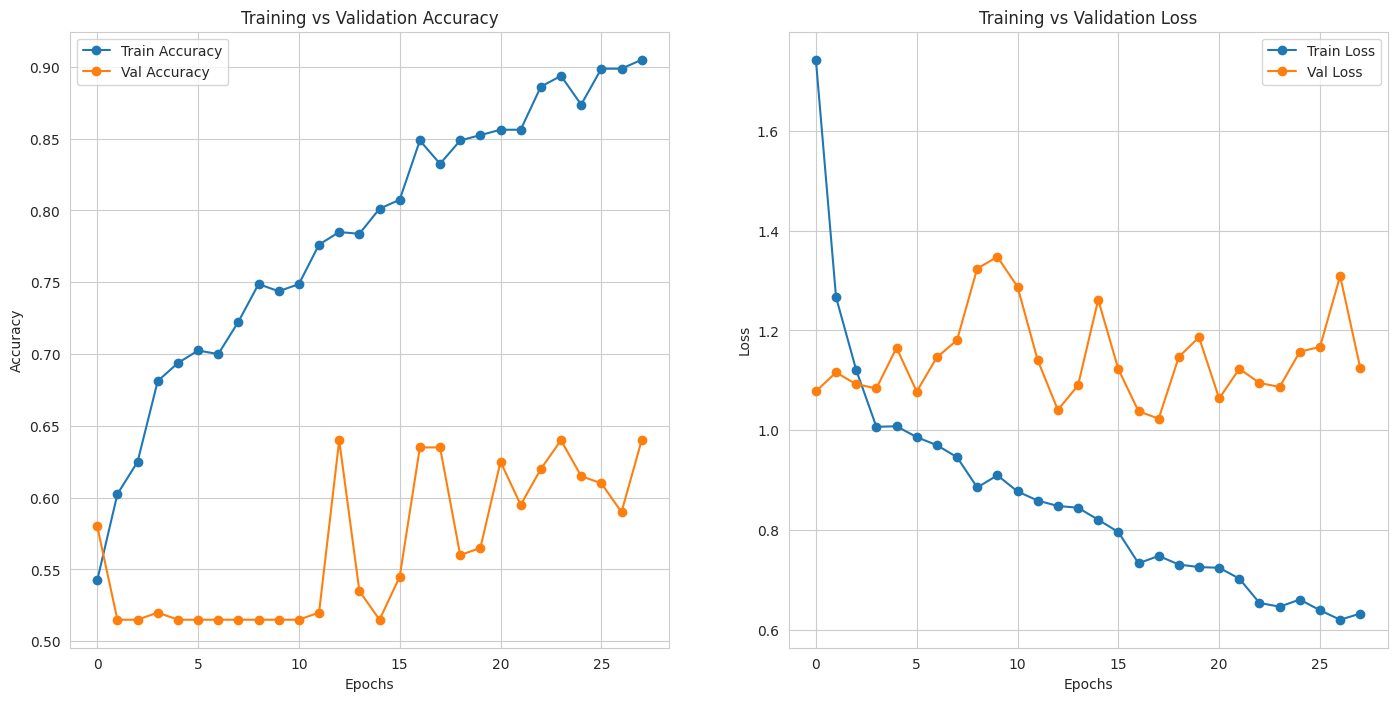

In [19]:
plt.figure(figsize=(17, 8))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

In [20]:
y_pred_probs = model.predict(x_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step


In [21]:
threshold = 0.5 

y_pred_classes = (y_pred_probs >= threshold).astype(int).flatten()
y_test_flattened = np.array(y_test).flatten()

In [22]:
incorrect_prediction_count = np.sum(y_pred_classes != y_test_flattened)
calculated_accuracy = accuracy_score(y_test_flattened, y_pred_classes)
error_rate = (incorrect_prediction_count / len(y_test_flattened)) * 100

In [23]:
print(f"Number of incorrect predictions: {incorrect_prediction_count}")
print(f"Error rate: {error_rate:.2f}%")
print(f"Calculated Test Accuracy: {calculated_accuracy * 100:.2f}%")

Number of incorrect predictions: 73
Error rate: 36.50%
Calculated Test Accuracy: 63.50%


In [24]:
print(classification_report(y_test_flattened, y_pred_classes))

              precision    recall  f1-score   support

           0       0.61      0.80      0.69       103
           1       0.68      0.46      0.55        97

    accuracy                           0.64       200
   macro avg       0.65      0.63      0.62       200
weighted avg       0.65      0.64      0.62       200



## 5. Final Performance Evaluation & Diagnostics

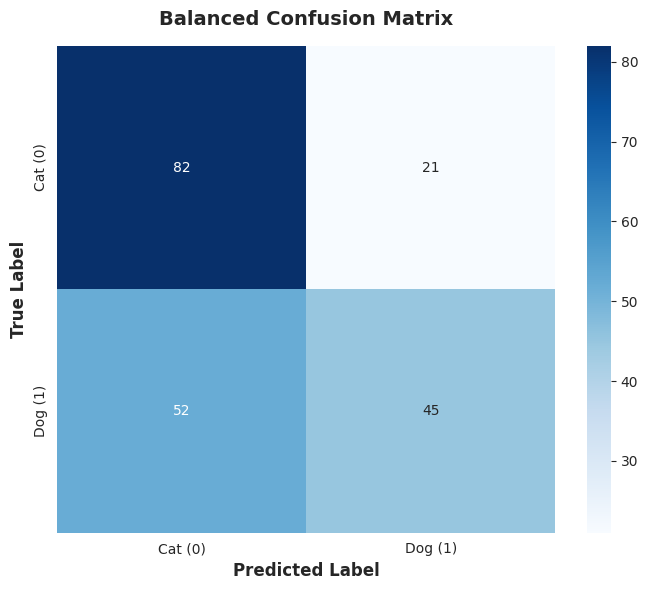

In [25]:
cm = confusion_matrix(y_test_flattened, y_pred_classes)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Cat (0)", "Dog (1)"],
    yticklabels=["Cat (0)", "Dog (1)"],
)

plt.xlabel("Predicted Label", fontsize=12, fontweight="bold")
plt.ylabel("True Label", fontsize=12, fontweight="bold")
plt.title("Balanced Confusion Matrix", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

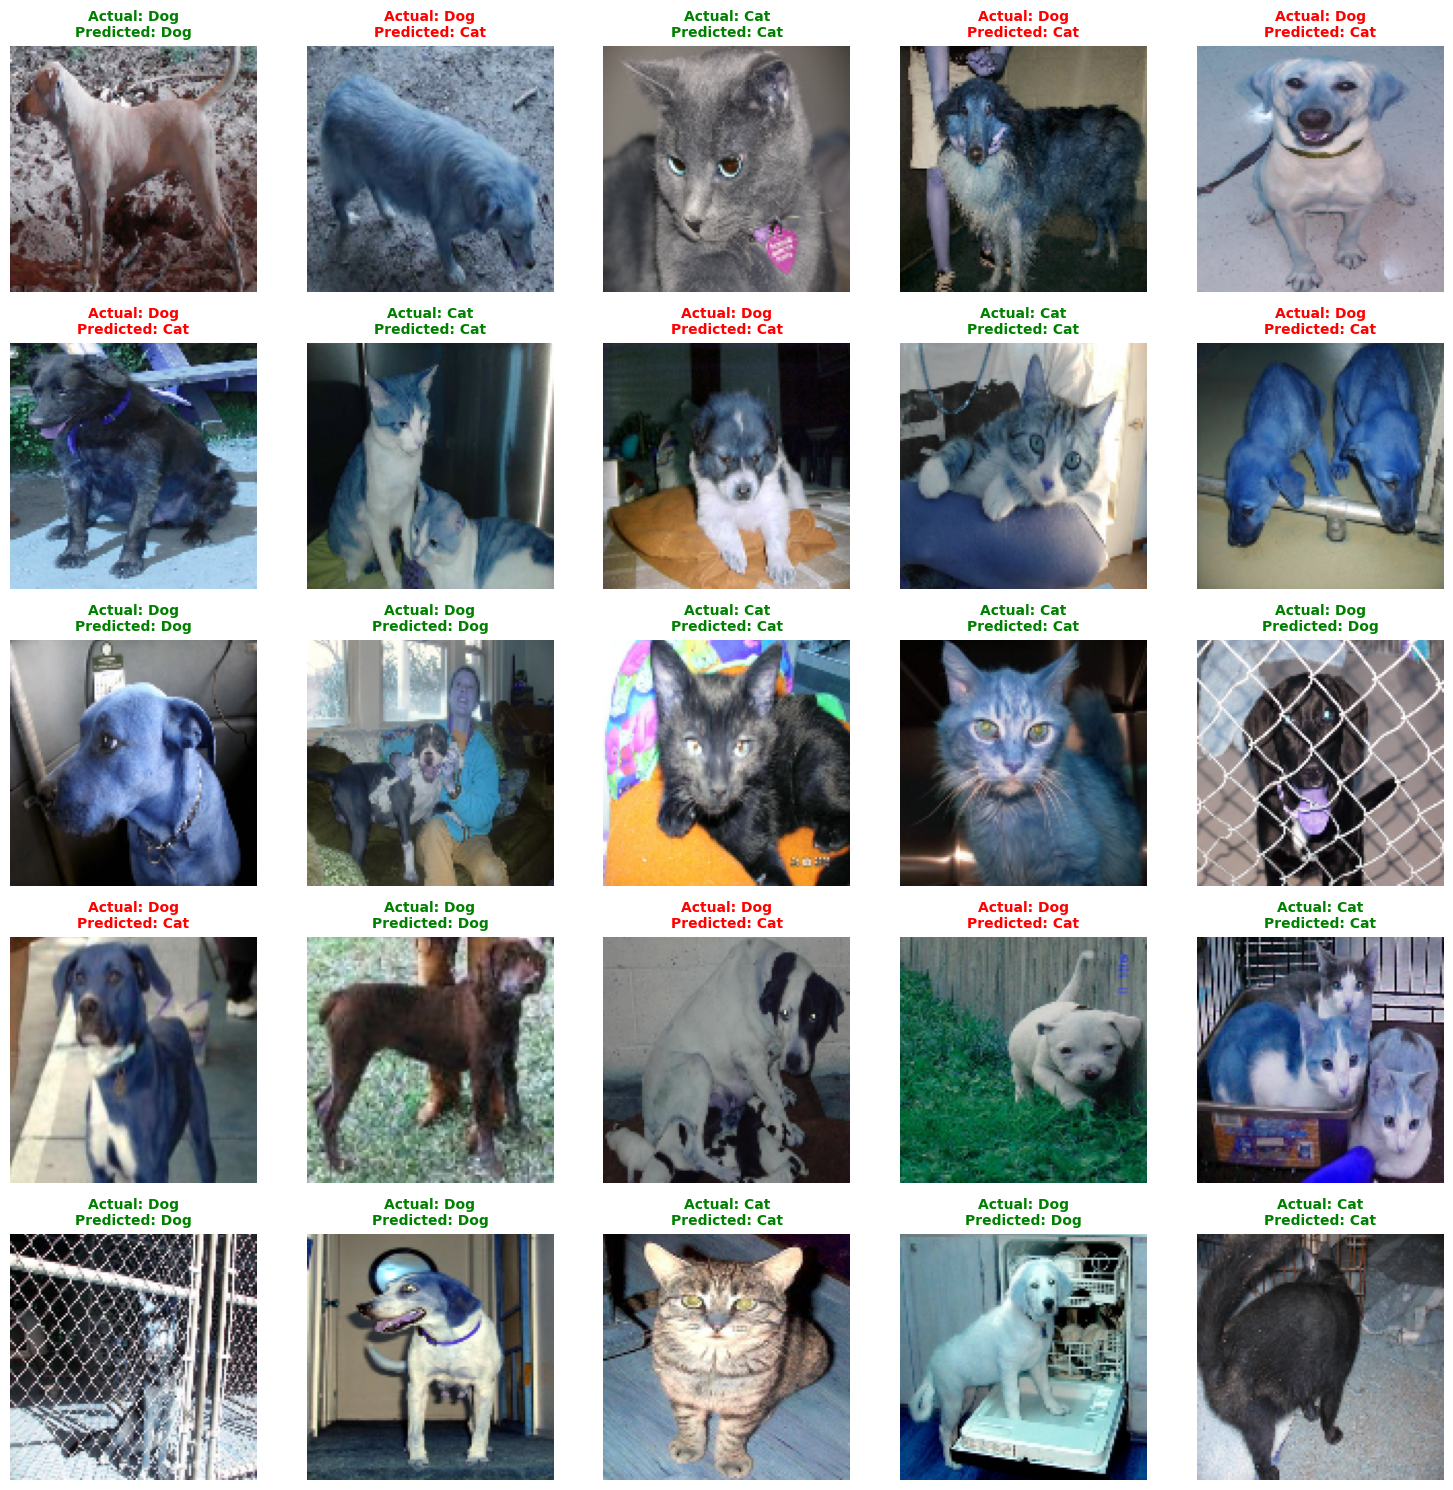

In [26]:
num_samples = len(x_test)
n_images = 25
random_indices = np.random.choice(num_samples, size=n_images, replace=False)

x_test_sample = x_test[random_indices]
y_test_array = np.array(y_test).flatten()
actual_labels = y_test_array[random_indices]

sample_predictions = y_pred_probs[random_indices]

predicted_labels = (sample_predictions >= threshold).astype(int).flatten()

binary_label_map = {0: "Cat", 1: "Dog"}

plt.figure(figsize=(15, 15))

for i in range(n_images):
    plt.subplot(5, 5, i + 1)

    plt.imshow(x_test_sample[i])

    actual_name = binary_label_map.get(
        actual_labels[i], f"Class {actual_labels[i]}"
    )
    predicted_name = binary_label_map.get(
        predicted_labels[i], f"Class {predicted_labels[i]}"
    )

    color = "green" if actual_labels[i] == predicted_labels[i] else "red"

    plt.title(
        f"Actual: {actual_name}\nPredicted: {predicted_name}",
        fontsize=10,
        color=color,
        fontweight="bold",
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

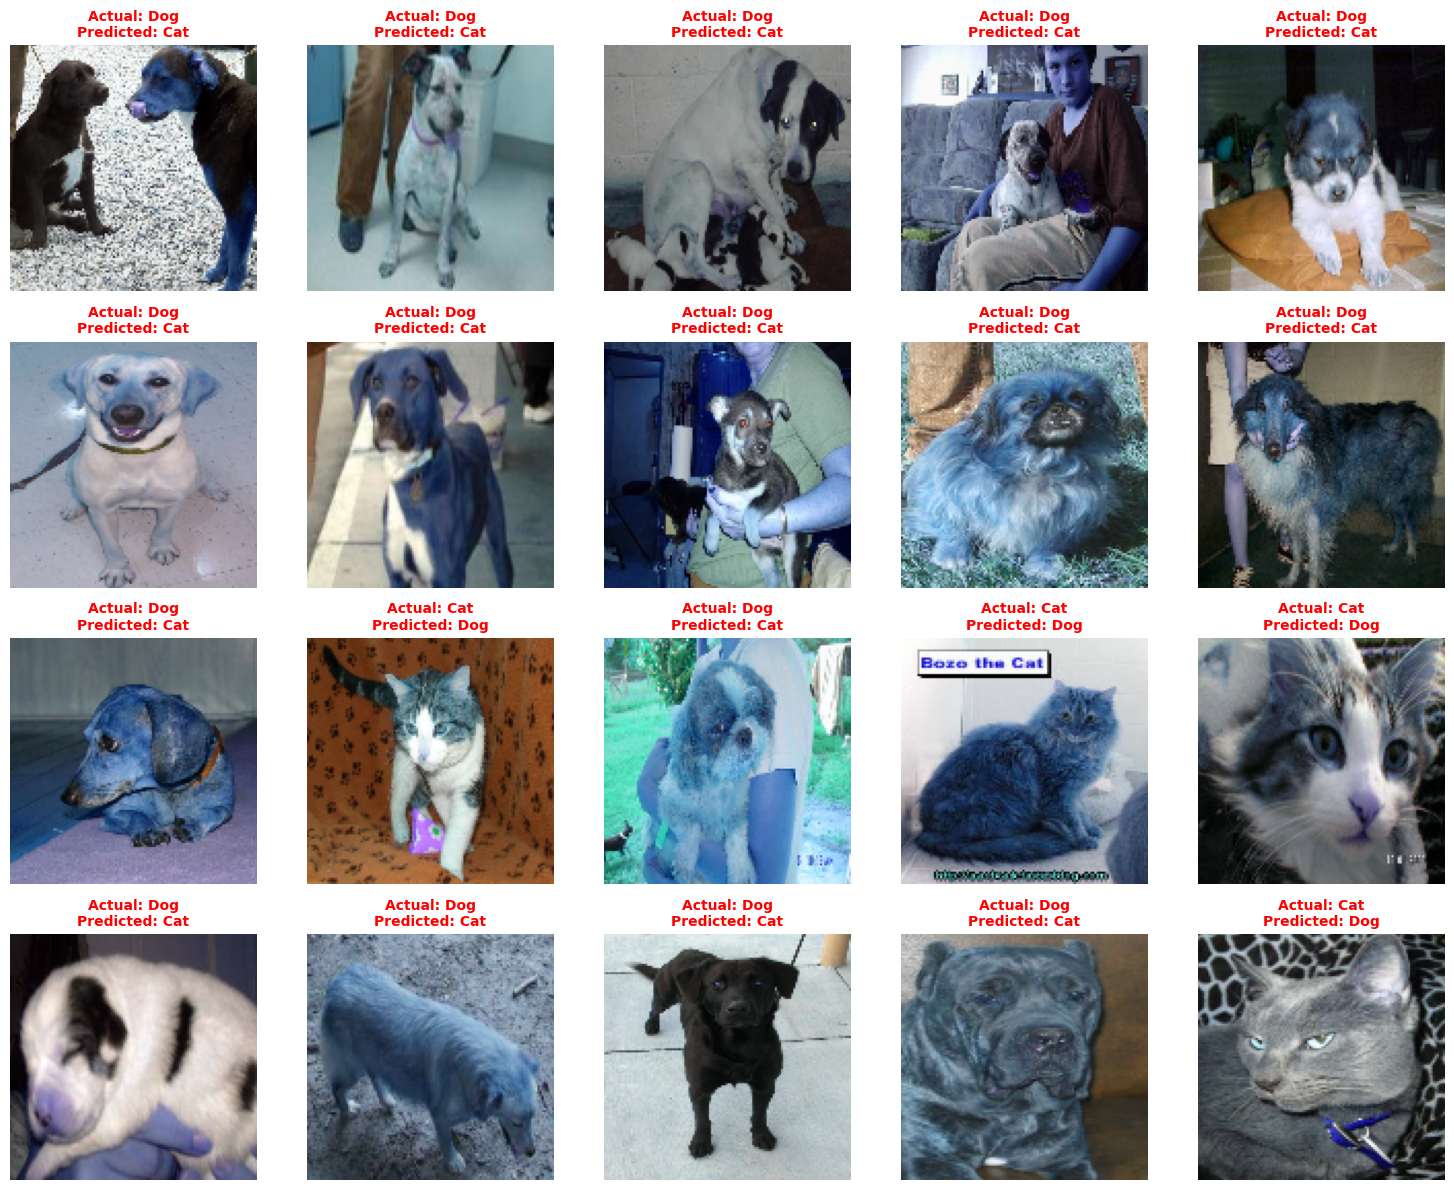

In [27]:
error_indexes = np.where(y_pred_classes != y_test_flattened)[0]

binary_label_map = {0: "Cat", 1: "Dog"}

if len(error_indexes) > 0:
    plt.figure(figsize=(15, 12))

    for i, index in enumerate(error_indexes[:20]):
        plt.subplot(4, 5, i + 1)

        plt.imshow(x_test[index])

        actual_label_val = y_test_flattened[index]
        predicted_label_val = y_pred_classes[index]

        actual_name = binary_label_map.get(
            actual_label_val, f"Class {actual_label_val}"
        )
        predicted_name = binary_label_map.get(
            predicted_label_val, f"Class {predicted_label_val}"
        )

        plt.title(
            f"Actual: {actual_name}\nPredicted: {predicted_name}",
            color="red",
            fontsize=10,
            fontweight="bold",
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [28]:
model.save('catdog.keras')
display(FileLink('catdog.keras'))

/kaggle/working/catdog.keras

In [33]:
model.save('catdog.h5')
display(FileLink('catdog.h5'))

/kaggle/working/catdog.h5

In [56]:
weights = model.get_weights() 

np.savez('catdog_weights.npz', *weights)

In [57]:
display(FileLink('catdog_weights.npz'))

/kaggle/working/catdog_weights.npz